In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

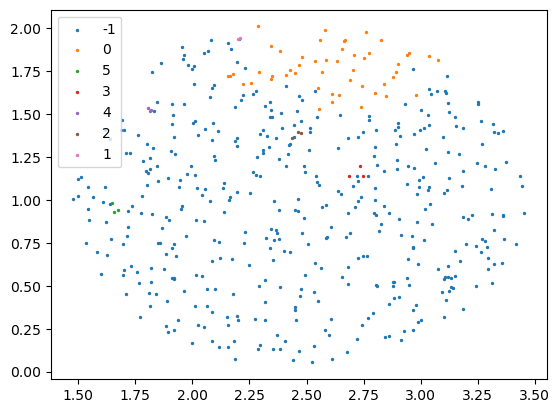

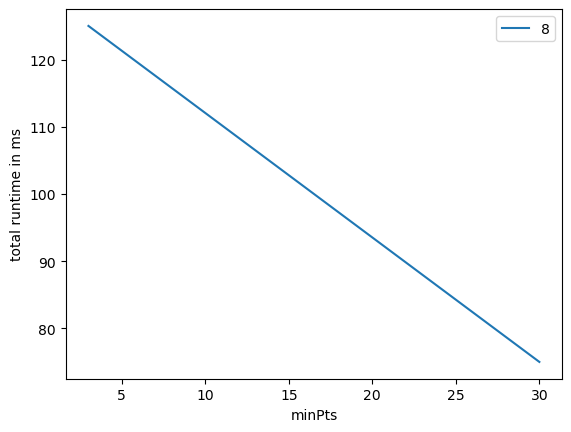

/tmp/ipykernel_42106/1443213452.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


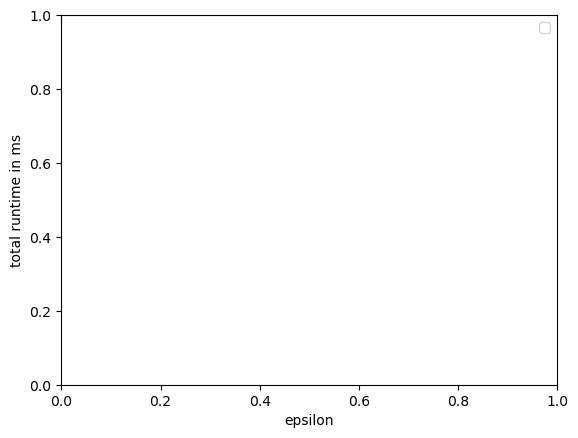

In [4]:
points_name = "points.csv"
timing_name = "timing.csv"
save_directory = "results/"

Path(save_directory).mkdir(exist_ok=True)

points_df = pd.read_csv(points_name)
timing_df = pd.read_csv(timing_name)

for cluster in points_df["clusterId"].unique():
    cluster_df = points_df[points_df["clusterId"] == cluster]
    plt.scatter(cluster_df["x0"], cluster_df["x1"], s=2, label=str(cluster))
plt.legend()
plt.show()

for dataset in timing_df["dataset"].unique():
    timing_dataset_df = timing_df[timing_df["dataset"] == dataset]
    for epsilon in timing_dataset_df["epsilon"].unique():
        timing_dataset_epsilon_df = timing_dataset_df[timing_dataset_df["epsilon"] == epsilon].sort_values(by="minPts")
        if (not timing_dataset_epsilon_df.empty) and len(timing_dataset_epsilon_df) > 1:
            for num_of_processes in timing_dataset_epsilon_df["numProcesses"].unique():
                timing_dataset_epsilon_nump_df = timing_dataset_epsilon_df[timing_dataset_epsilon_df["numProcesses"] == num_of_processes]
                if (not timing_dataset_epsilon_nump_df.empty) and len(timing_dataset_epsilon_nump_df) > 1:
                    plt.plot(timing_dataset_epsilon_nump_df["minPts"], timing_dataset_epsilon_nump_df["totalMs"], label=str(num_of_processes))
            plt.xlabel("minPts")
            plt.ylabel("total runtime in ms")
            plt.legend()
            plt.show()
    for minPts in timing_dataset_df["minPts"].unique():
        timing_dataset_minpts_df = timing_dataset_df[timing_dataset_df["minPts"] == minPts].sort_values(by="epsilon")
        if (not timing_dataset_minpts_df.empty) and len(timing_dataset_minpts_df) > 1:
            for num_of_processes in timing_dataset_minpts_df["numProcesses"].unique():
                timing_dataset_minpts_nump_df = timing_dataset_minpts_df[timing_dataset_minpts_df["numProcesses"] == num_of_processes]
                if (not timing_dataset_minpts_nump_df.empty) and len(timing_dataset_minpts_nump_df) > 1:
                    plt.plot(timing_dataset_minpts_nump_df["epsilon"], timing_dataset_minpts_nump_df["totalMs"], label=str(num_of_processes))
            plt.xlabel("epsilon")
            plt.ylabel("total runtime in ms")
            plt.legend()
            plt.show()